In [1]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt 


In [2]:
model = YOLO("yolov8n.pt")

In [3]:
from pathlib import Path

train_path = Path("../data/plate_dataset/images/train")
val_path = Path("../data/plate_dataset/images/valid")

train_images = list(train_path.glob("*"))
val_images = list(val_path.glob("*"))

print("Number of train images:", len(train_images))
print("Number of val images:", len(val_images))
print("Total images:", len(train_images) + len(val_images))

Number of train images: 7057
Number of val images: 2048
Total images: 9105


In [4]:
import os
import random
import shutil


def create_subset(image_dir, label_dir, out_img_dir, out_lbl_dir, sample_size):

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    images = os.listdir(image_dir)

    selected = random.sample(images, sample_size)

    for img in selected:

        label = os.path.splitext(img)[0] + ".txt"

        shutil.copy(
            os.path.join(image_dir, img),
            os.path.join(out_img_dir, img)
        )

        shutil.copy(
            os.path.join(label_dir, label),
            os.path.join(out_lbl_dir, label)
        )

    print(f"Created subset with {sample_size} images")


# -------------------------------
# TRAIN SUBSET
# -------------------------------

create_subset(
    "../data/plate_dataset/images/train",
    "../data/plate_dataset/labels/train",
    "../data/plate_dataset/images/train_small",
    "../data/plate_dataset/labels/train_small",
    sample_size=1000
)


# -------------------------------
# VALIDATION SUBSET
# -------------------------------

create_subset(
    "../data/plate_dataset/images/valid",
    "../data/plate_dataset/labels/valid",
    "../data/plate_dataset/images/valid_small",
    "../data/plate_dataset/labels/valid_small",
    sample_size=150
)

Created subset with 1000 images
Created subset with 150 images


In [5]:
results = model.train(
    data = "../data/plate_dataset/plate_data.yaml",
    epochs = 40,
    imgsz = 640,
    batch = 8,
    project = "../plate",
    name = "plate_detector"
)

Ultralytics 8.4.21 🚀 Python-3.11.15 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/plate_dataset/plate_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [6]:
print(os.listdir("runs/plate"))
print(os.listdir("runs/plate/plate_detector/weights"))

['plate_detector']
['last.pt', 'best.pt']


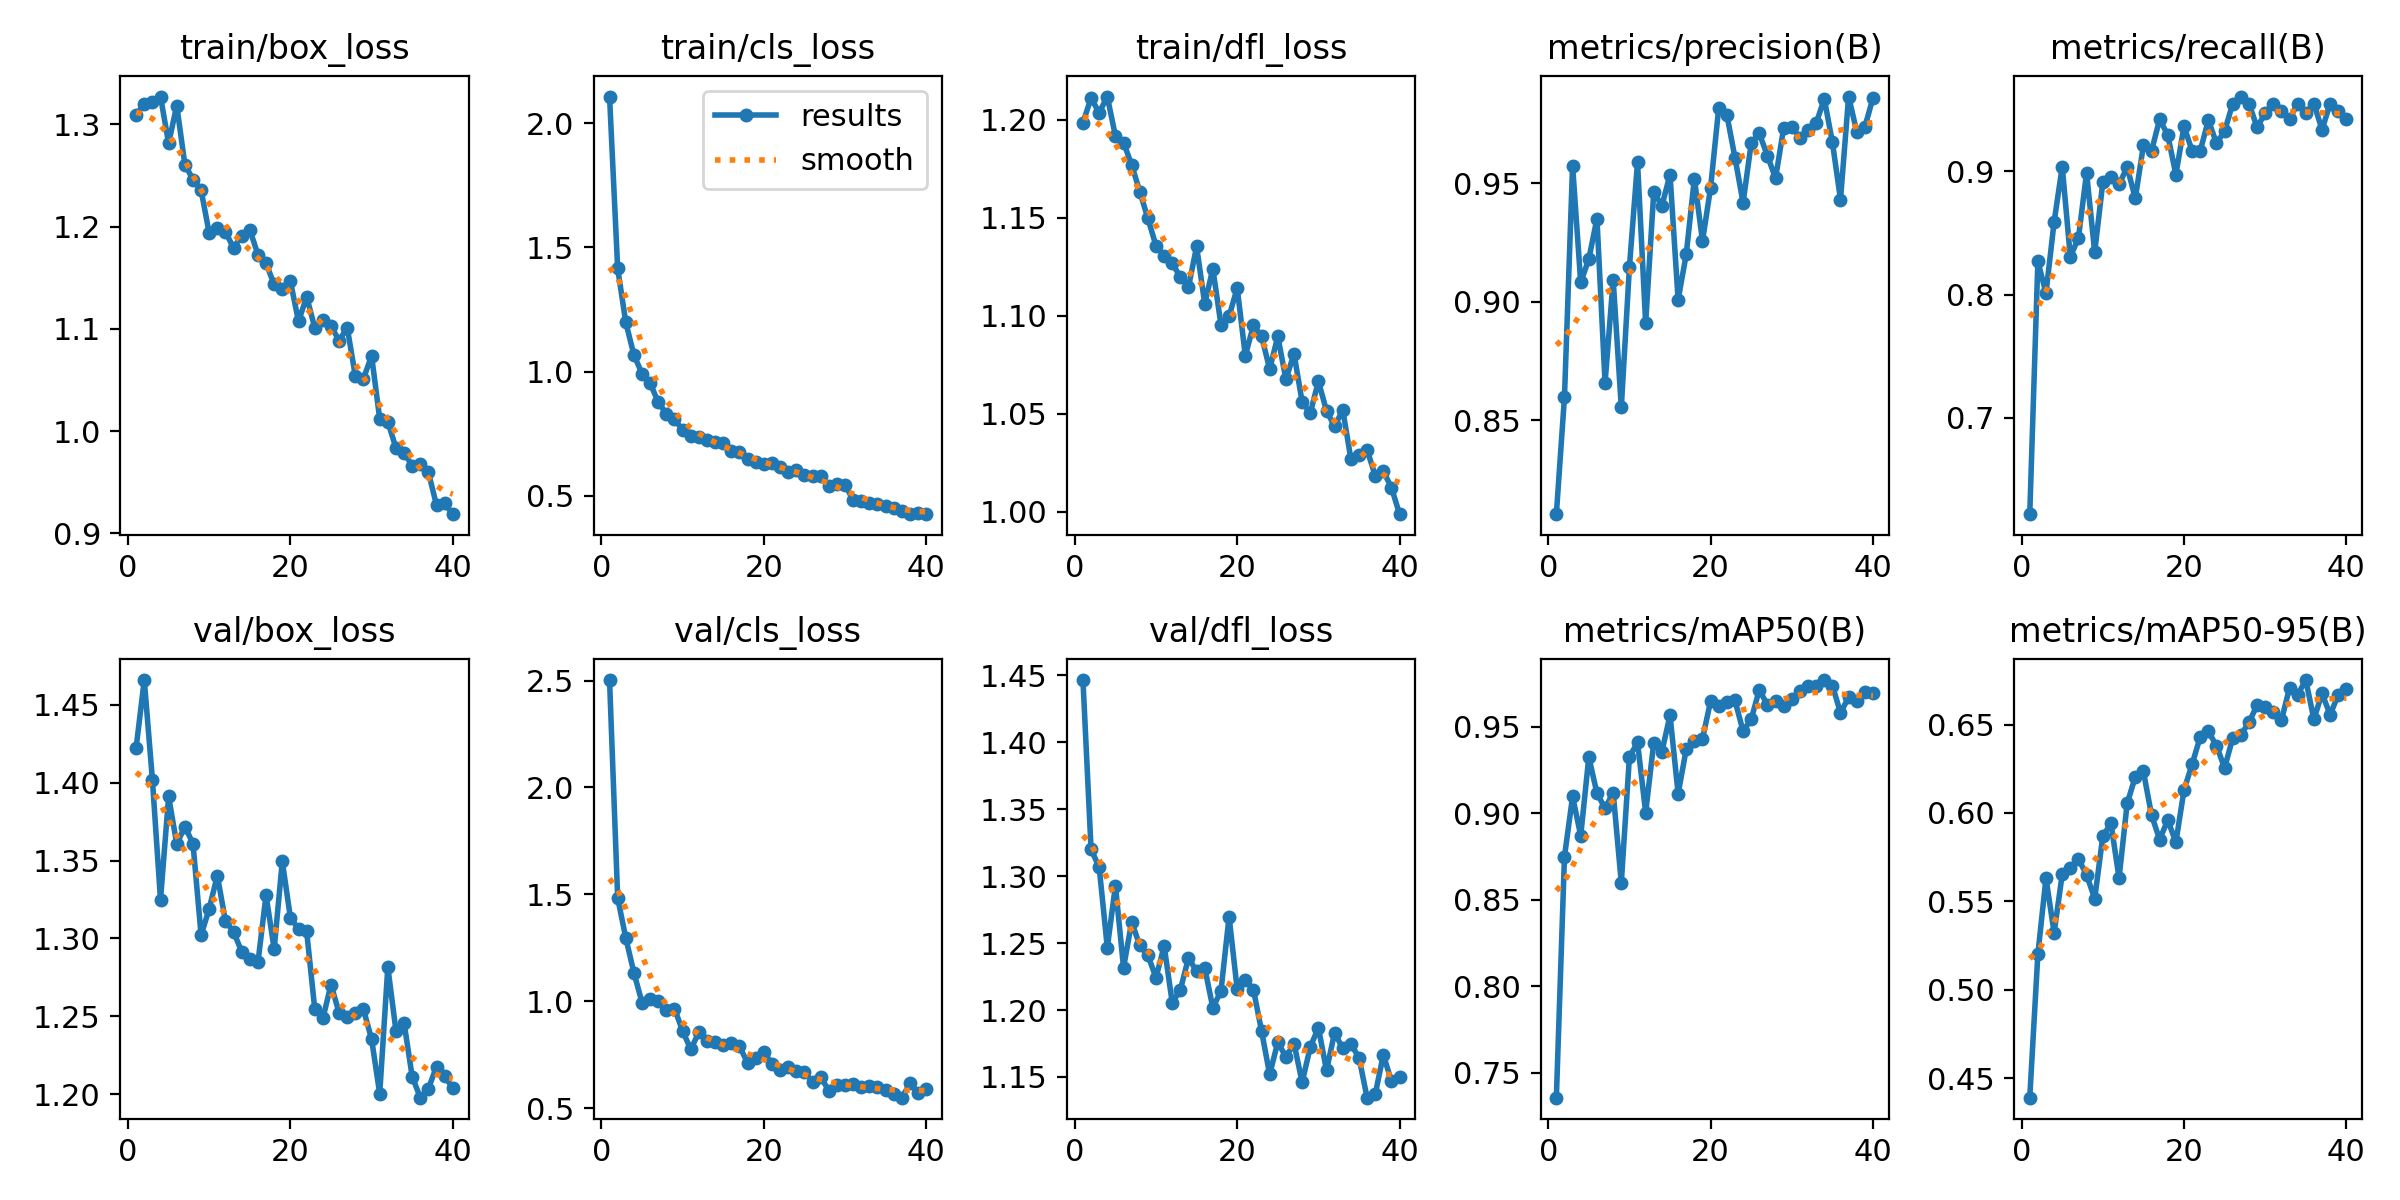

In [7]:
from IPython.display import Image

Image("runs/plate/plate_detector/results.png")

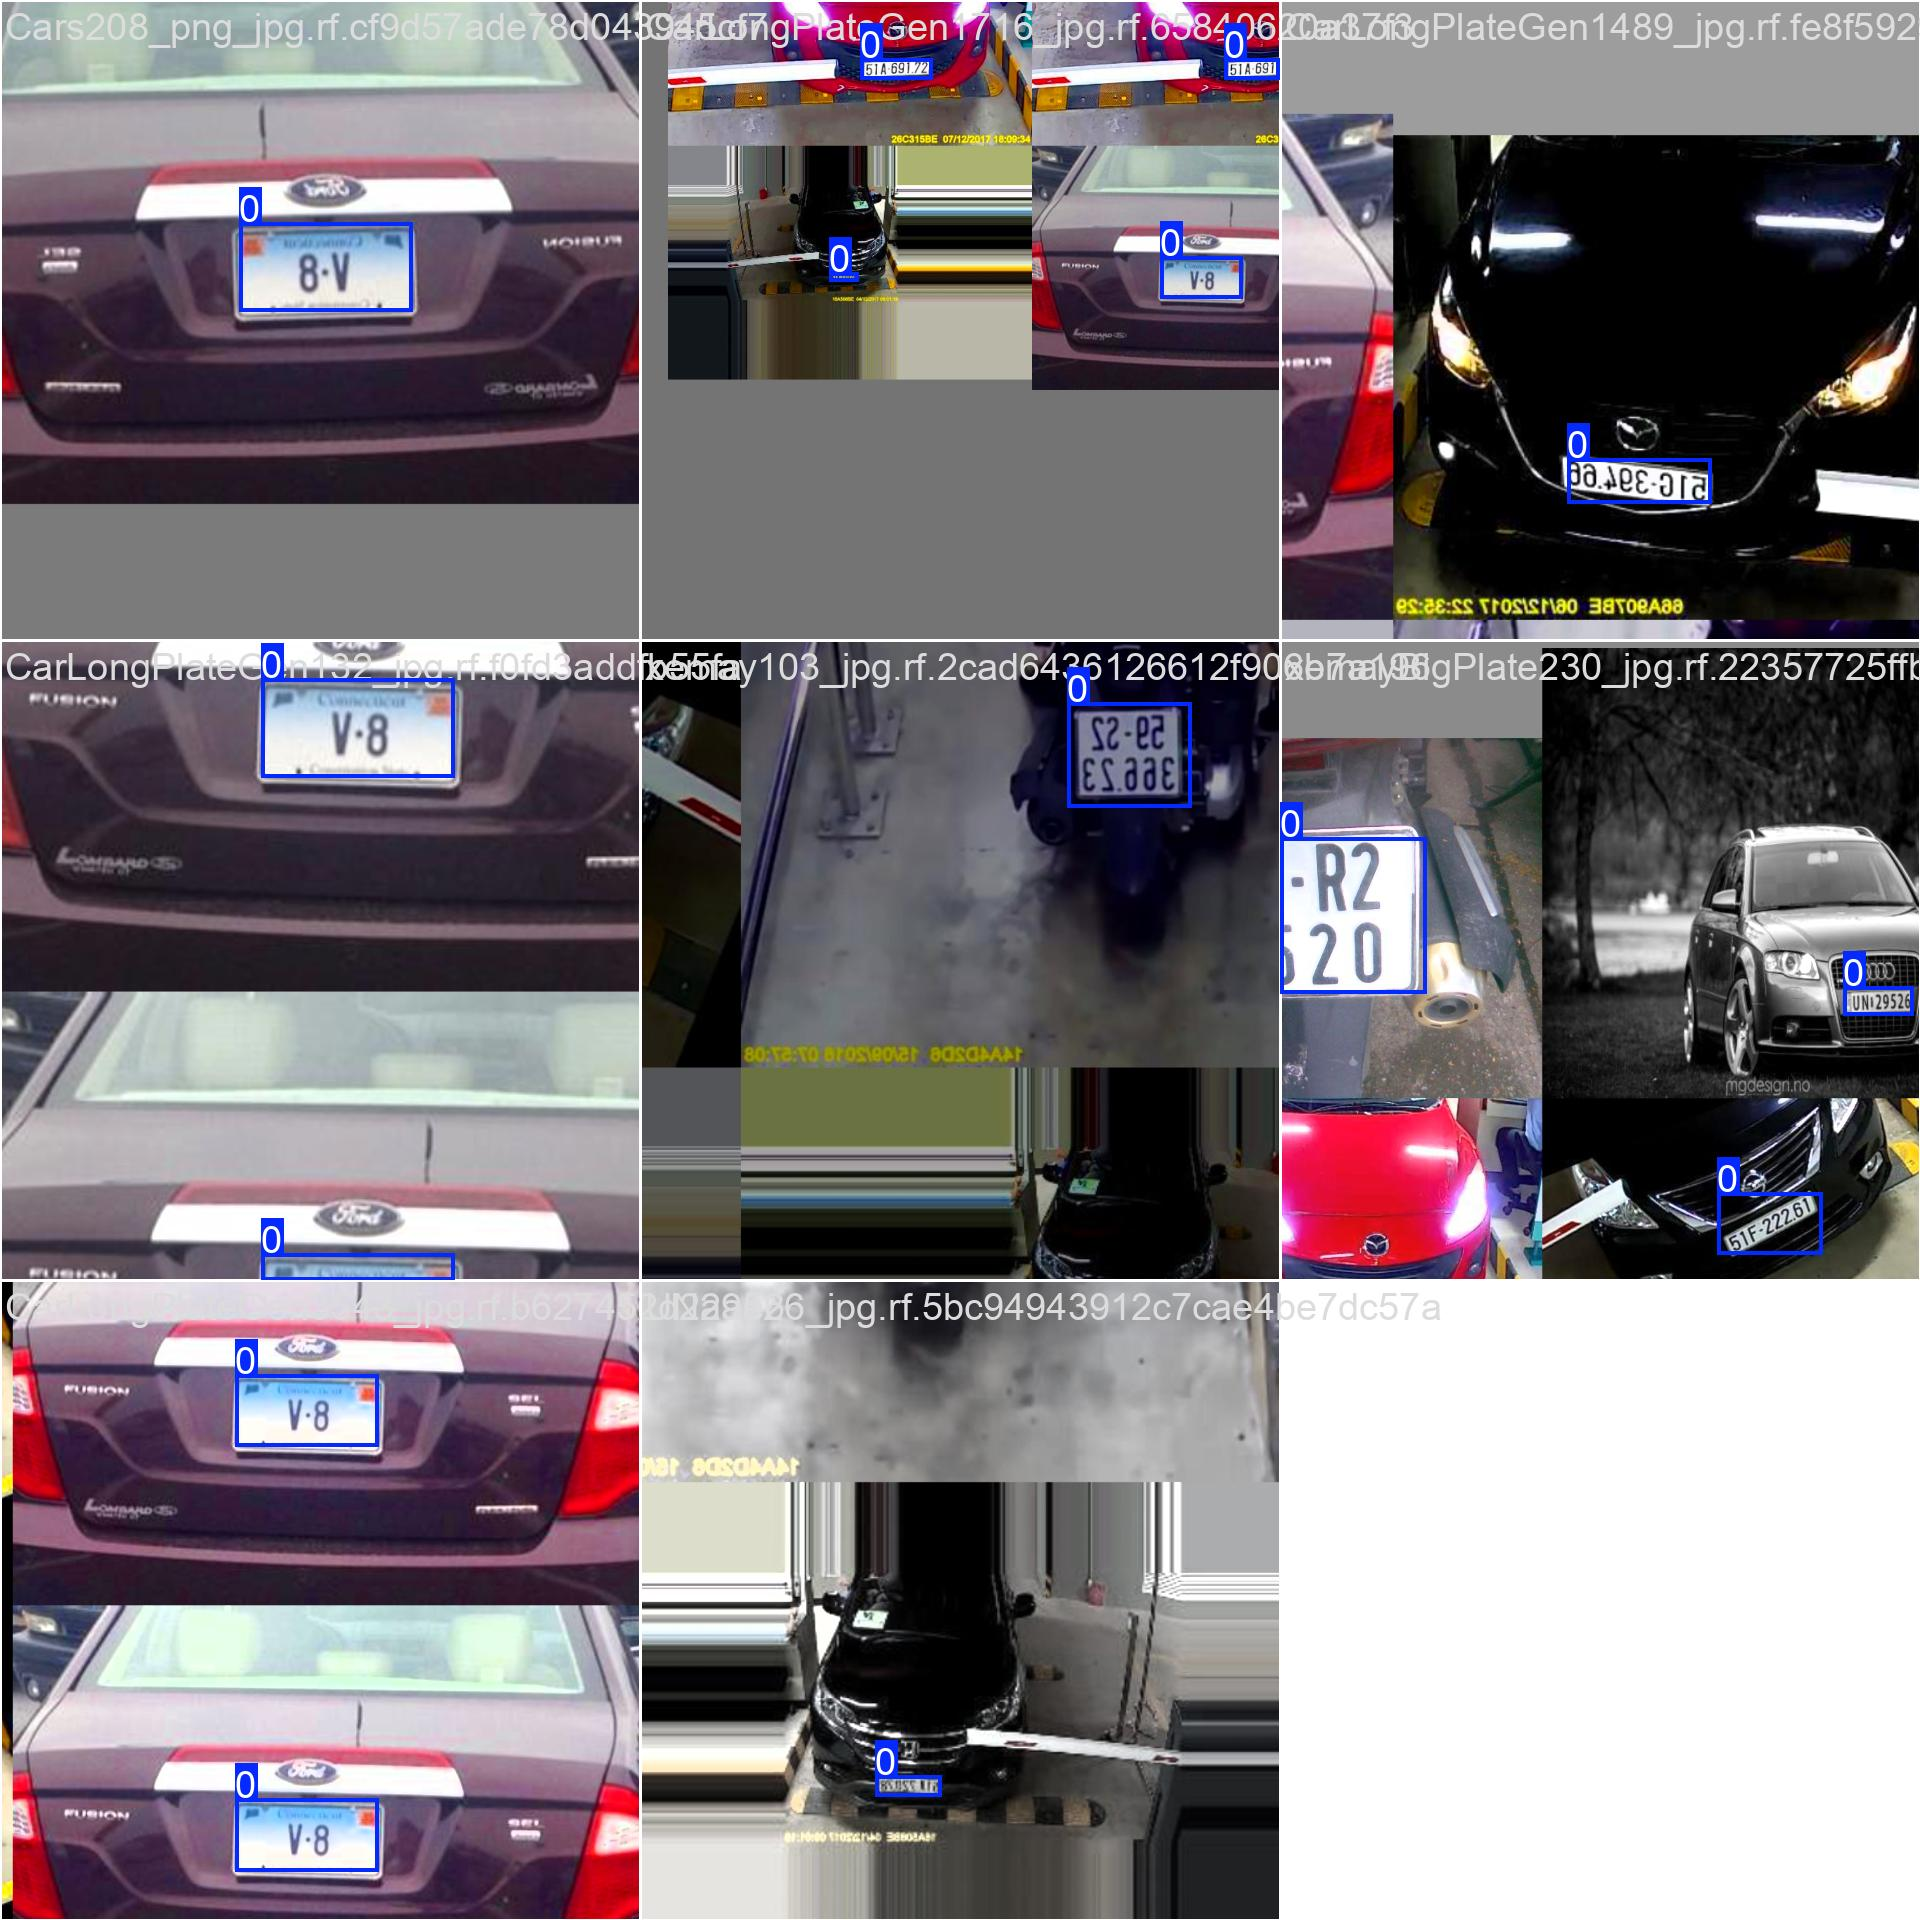

In [8]:
Image("runs/plate/plate_detector/train_batch0.jpg")

In [9]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.21 🚀 Python-3.11.15 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 151.4±83.1 MB/s, size: 43.7 KB)
val: Scanning /home/lurvik/Traffic_Anamoly_Detection/data/plate_dataset/labels/valid_small.cache... 150 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 89.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.2it/s 8.4s.9ss
                   all        150        156      0.967      0.949      0.974      0.675
Speed: 0.9ms preprocess, 49.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/lurvik/Traffic_Anamoly_Detection/notebooks/runs/detect/val3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.met

In [10]:
import shutil

src = "runs/plate/plate_detector/weights/best.pt"
dst = "../models/plate_detector.pt"

shutil.copy(src, dst)

print("Model saved to models folder")

Model saved to models folder


In [11]:
model_test = YOLO("../models/plate_detector.pt")

model_test.predict(
    source="../data/videos/traffic_video.mp4",
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 384x640 1 License_Plate, 57.1ms
video 1/1 (frame 2/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 384x640 1 License_Plate, 38.9ms
video 1/1 (frame 3/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 384x640 (no detections), 38.2ms
video 1/1 (frame 4/557) /home/lurvik/Traf

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'License_Plate'}
 obb: None
 orig_img: array([[[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        [[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        [[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        ...,
 
        [[114, 111, 112],
         [114, 111, 112],
         [114, 111, 112],
         ...,
         [106, 103, 104],
         [106, 103, 104],
         [106, 103, 104]],
 
        [[113, 110, 111],
         [113, 110, 111],
         [113, 110, 111],
         ...,
         [1

In [12]:
import cv2

input_video = "runs/detect/predict3/traffic_video.avi"
output_video = "runs/detect/predict3/output.mp4"

cap = cv2.VideoCapture(input_video)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)

cap.release()
out.release()

print("Conversion completed")

Conversion completed
